In [ ]:
215510P-Athapaththu AAND

In [4]:
!pip install opencv-python-headless matplotlib numpy scikit-learn -q

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

In [15]:
import numpy as np
import requests
from io import StringIO

BASE = "https://raw.githubusercontent.com/NalinDhanuddheera/Assignment-2---Fitting-and-Alignment/main/data"

def load_csv_from_github(raw_url):
    response = requests.get(raw_url)
    if response.status_code == 200:
        print(f"Loaded successfully: {raw_url.split('/')[-1]}")
        return np.genfromtxt(StringIO(response.text), delimiter=",", skip_header=1)
    else:
        print(f"Failed to load: {response.status_code}")
        return None





In [16]:
# Load lines.csv 
csv_url = f"{BASE}/lines.csv"
D = load_csv_from_github(csv_url)

X_cols = D[:, :3]
Y_cols = D[:, 3:]

# Quick check
print(f"\nData shape: {D.shape}")
print(f"First row: {D[0]}")

Loaded successfully: lines.csv

Data shape: (100, 6)
First row: [ -5.30547099  -4.06009155  -5.26129006 -12.66633342  -3.79615021
   3.69171161]


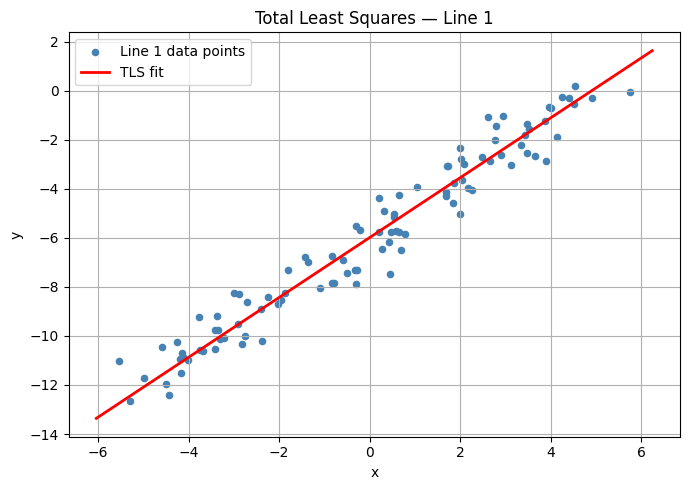

In [20]:

# Take only the first line data
x1 = X_cols[:, 0]
y1 = Y_cols[:, 0]
pts_line1 = np.column_stack([x1, y1])

def fit_line_tls(pts):
    
    mean = pts.mean(axis=0)
    centered = pts - mean
    _, _, Vt = np.linalg.svd(centered)
    a, b = Vt[-1]                        
    c = -(a * mean[0] + b * mean[1])
    return a, b, c

a, b, c = fit_line_tls(pts_line1)

# ── Plot 
xs = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 200)
ys = (-a * xs - c) / b

plt.figure(figsize=(7, 5))
plt.scatter(x1, y1, s=20, color='steelblue', label='Line 1 data points')
plt.plot(xs, ys, 'r-', linewidth=2, label='TLS fit')
plt.title('Total Least Squares — Line 1')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('q1a_tls.png', dpi=150)
plt.show()

Total mixed points: 300
  Line 1: -0.4667x + -0.8844y + 1.8017 = 0  | y = -0.5277x + 2.0372  | 62 inliers
  Line 2: 0.7319x + -0.6815y + 0.7588 = 0  | y = 1.0740x + 1.1135  | 49 inliers
  Line 3: 0.7852x + -0.6192y + -3.6203 = 0  | y = 1.2681x + -5.8466  | 45 inliers


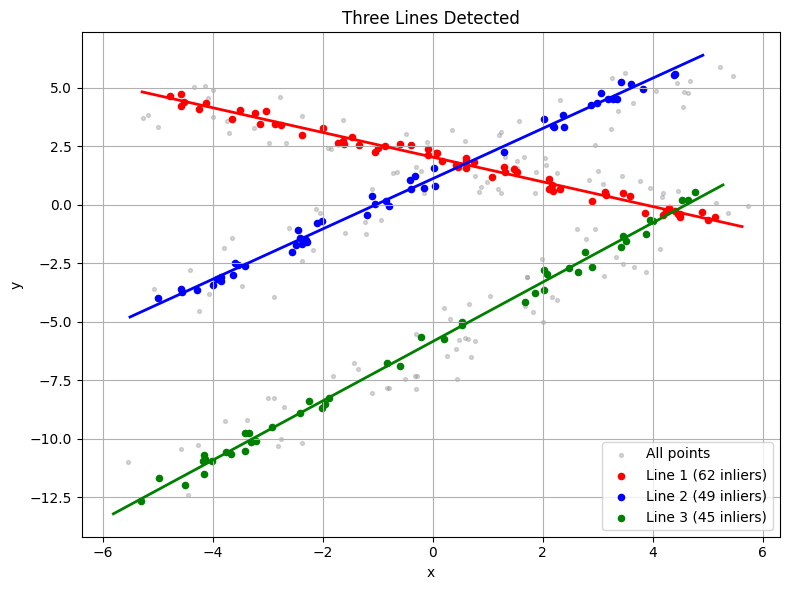

In [22]:

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
all_points = np.column_stack([X_all, Y_all])
print(f"Total mixed points: {len(all_points)}")

def point_line_dist(pts, a, b, c):
    return np.abs(a * pts[:, 0] + b * pts[:, 1] + c) / np.sqrt(a**2 + b**2)

def ransac_line(pts, n_iter=2000, threshold=0.3):
    
    best_inliers = None
    best_count   = 0
    n = len(pts)

    for _ in range(n_iter):
        idx = np.random.choice(n, 2, replace=False)
        sample = pts[idx]

        dx = sample[1, 0] - sample[0, 0]
        dy = sample[1, 1] - sample[0, 1]
        a, b = dy, -dx
        c = -(a * sample[0, 0] + b * sample[0, 1])
        norm = np.sqrt(a**2 + b**2)
        if norm < 1e-10:
            continue
        a, b, c = a / norm, b / norm, c / norm

        dists   = point_line_dist(pts, a, b, c)
        inliers = np.where(dists < threshold)[0]

        if len(inliers) > best_count:
            best_count   = len(inliers)
            best_inliers = inliers
            
    a, b, c = fit_line_tls(pts[best_inliers])
    return a, b, c, best_inliers

np.random.seed(42)
remaining = np.arange(len(all_points))
lines     = []
colors    = ['red', 'blue', 'green']

for i in range(3):
    pts_rem = all_points[remaining]
    a, b, c, local_idx = ransac_line(pts_rem)
    global_idx = remaining[local_idx]
    lines.append((a, b, c, global_idx))
    print(f"  Line {i+1}: {a:.4f}x + {b:.4f}y + {c:.4f} = 0  "
        f"| y = {-a/b:.4f}x + {-c/b:.4f}  | {len(global_idx)} inliers")
    remaining = np.setdiff1d(remaining, global_idx)

# ── Plot 
plt.figure(figsize=(8, 6))
plt.scatter(X_all, Y_all, s=8, alpha=0.3, color='gray', label='All points')

for i, (a, b, c, inliers) in enumerate(lines):
    plt.scatter(all_points[inliers, 0], all_points[inliers, 1],
                s=20, color=colors[i], label=f'Line {i+1} ({len(inliers)} inliers)')
    xs = np.linspace(all_points[inliers, 0].min() - 0.5,
                    all_points[inliers, 0].max() + 0.5, 200)
    ys = (-a * xs - c) / b
    plt.plot(xs, ys, color=colors[i], linewidth=2)

plt.title('Three Lines Detected')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('q1b_ransac.png', dpi=150)
plt.show()